# Stunting Prediction Modeling and Explainable AI

Machine learning models for early stunting risk prediction, evaluates model performance, performs threshold tuning, and applies SHAP and LIME for model interpretation.


## 1. Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, make_scorer
)

import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
#  PUBLICATION STYLE CONFIGURATION
# ─────────────────────────────────────────────

PALETTE = {
    "primary":   "#355C7D",   # Primary Blue
    "teal":      "#2A9D8F",   # Secondary Teal
    "orange":    "#F4A261",   # Accent Orange
    "red":       "#E76F51",   # Risk Red
    "gray":      "#6C757D",   # Neutral Gray
    "light":     "#D9E8F0",   # Light wash
    "bg":        "#FAFAFA",   # Near-white background
}

MODEL_COLORS = [PALETTE["primary"], PALETTE["teal"], PALETTE["orange"]]

plt.rcParams.update({
    # Figure
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    # Font — use DejaVu Serif for close-to-Times look
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Georgia", "serif"],

    # Sizes
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "legend.title_fontsize": 9,
    "axes.titleweight": "bold",
    "axes.labelweight": "normal",

    # Spines & ticks
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "grid.color": "#CCCCCC",

    # Lines
    "lines.linewidth": 1.8,

    # Layout
    "figure.constrained_layout.use": False,
})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "Data/processed/dataset_final.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = MODEL_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False

RANDOM_STATE = 42


## 2. Visualization Helper Functions


In [2]:
# ─────────────────────────────────────────────
#  REUSABLE PUBLICATION HELPERS
# ─────────────────────────────────────────────

def save_figure(fig, filename, tight=True):
    """Save figure at 300 dpi with consistent settings."""
    if tight:
        fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    print(f"  Saved → {FIGURE_DIR / filename}")


def style_ax(ax, title=None, xlabel=None, ylabel=None,
             remove_top_right=True, grid_axis="both"):
    """Apply consistent academic styling to an Axes."""
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if remove_top_right:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    if grid_axis == "x":
        ax.grid(axis="x", alpha=0.25, linewidth=0.6, color="#CCCCCC")
        ax.grid(axis="y", visible=False)
    elif grid_axis == "y":
        ax.grid(axis="y", alpha=0.25, linewidth=0.6, color="#CCCCCC")
        ax.grid(axis="x", visible=False)
    elif grid_axis == "none":
        ax.grid(visible=False)
    return ax


def add_bar_labels(ax, fmt=".3f", fontsize=8.5, color="#333333",
                   pad=0.005, horizontal=False):
    """Add value labels to bar chart bars."""
    for container in ax.containers:
        if horizontal:
            ax.bar_label(container, fmt=f"{{:{fmt}}}", fontsize=fontsize,
                         color=color, padding=4)
        else:
            ax.bar_label(container, fmt=f"{{:{fmt}}}", fontsize=fontsize,
                         color=color, padding=3)


def get_model_color(idx):
    return MODEL_COLORS[idx % len(MODEL_COLORS)]


## 3. Load Dataset

The dataset used in this step is the machine-learning-ready dataset from Step 6.


In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


Dataset shape: 4886 rows and 19 columns


,child_gender,mother_education_level,mother_employment_status,mother_height_cm,improved_water,improved_sanitation,home_ownership,has_electricity,has_refrigerator,has_tv,is_stunted,mother_age_at_birth,is_teenage_mother,is_high_risk_mother_age,has_delivery_insurance,anc_clinic_midwife,anc_hospital,anc_traditional_other,anc_unknown
0,1,0,1,156.6,1.0,0.0,1.0,0.0,0.0,0.0,1,35.333333,0,1,0,0,0,0,1
1,1,1,0,151.6,1.0,0.0,1.0,0.0,0.0,0.0,1,36.750000,0,1,0,0,0,0,1
2,1,2,1,147.6,1.0,0.0,1.0,0.0,0.0,0.0,1,31.000000,0,0,0,0,0,0,1
3,0,0,0,140.1,1.0,0.0,1.0,0.0,0.0,0.0,0,30.416667,0,0,0,0,0,0,1
4,1,1,0,156.4,1.0,0.0,1.0,0.0,0.0,0.0,1,29.500000,0,0,0,0,0,0,1


## 4. Dataset Overview


In [4]:
display(df.describe())

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    display(missing_values)

print("\nTarget distribution:")
display(df["is_stunted"].value_counts())

print("\nTarget distribution percentage:")
display((df["is_stunted"].value_counts(normalize=True) * 100).round(2))


,child_gender,mother_education_level,mother_employment_status,mother_height_cm,improved_water,improved_sanitation,home_ownership,has_electricity,has_refrigerator,has_tv,is_stunted,mother_age_at_birth,is_teenage_mother,is_high_risk_mother_age,has_delivery_insurance,anc_clinic_midwife,anc_hospital,anc_traditional_other,anc_unknown
count,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000,4886.000000
mean,0.518625,2.552804,0.333402,151.696050,0.981989,0.748874,0.670692,0.991199,0.448629,0.922841,0.326852,27.328302,0.110725,0.148588,0.345068,0.481171,0.287147,0.006140,0.225542
std,0.499704,1.225612,0.471477,5.438581,0.133003,0.433705,0.470010,0.093408,0.497405,0.266871,0.469111,5.900061,0.313823,0.355718,0.475439,0.499696,0.452477,0.078125,0.417982
min,0.000000,0.000000,0.000000,104.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,148.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,22.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,0.000000,151.600000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,27.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,155.300000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,31.416667,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,5.000000,1.000000,174.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,50.916667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


No missing values found.

Target distribution:


is_stunted
0    3289
1    1597
Name: count, dtype: int64


Target distribution percentage:


is_stunted
0    67.31
1    32.69
Name: proportion, dtype: float64

## 5. Feature Engineering Summary

The final dataset includes engineered predictors such as mother_age_at_birth, teenage mother indicator, high-risk maternal age indicator, delivery insurance status, and one-hot encoded ANC location.


## 6. Exploratory Data Analysis


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/eda_overview.png


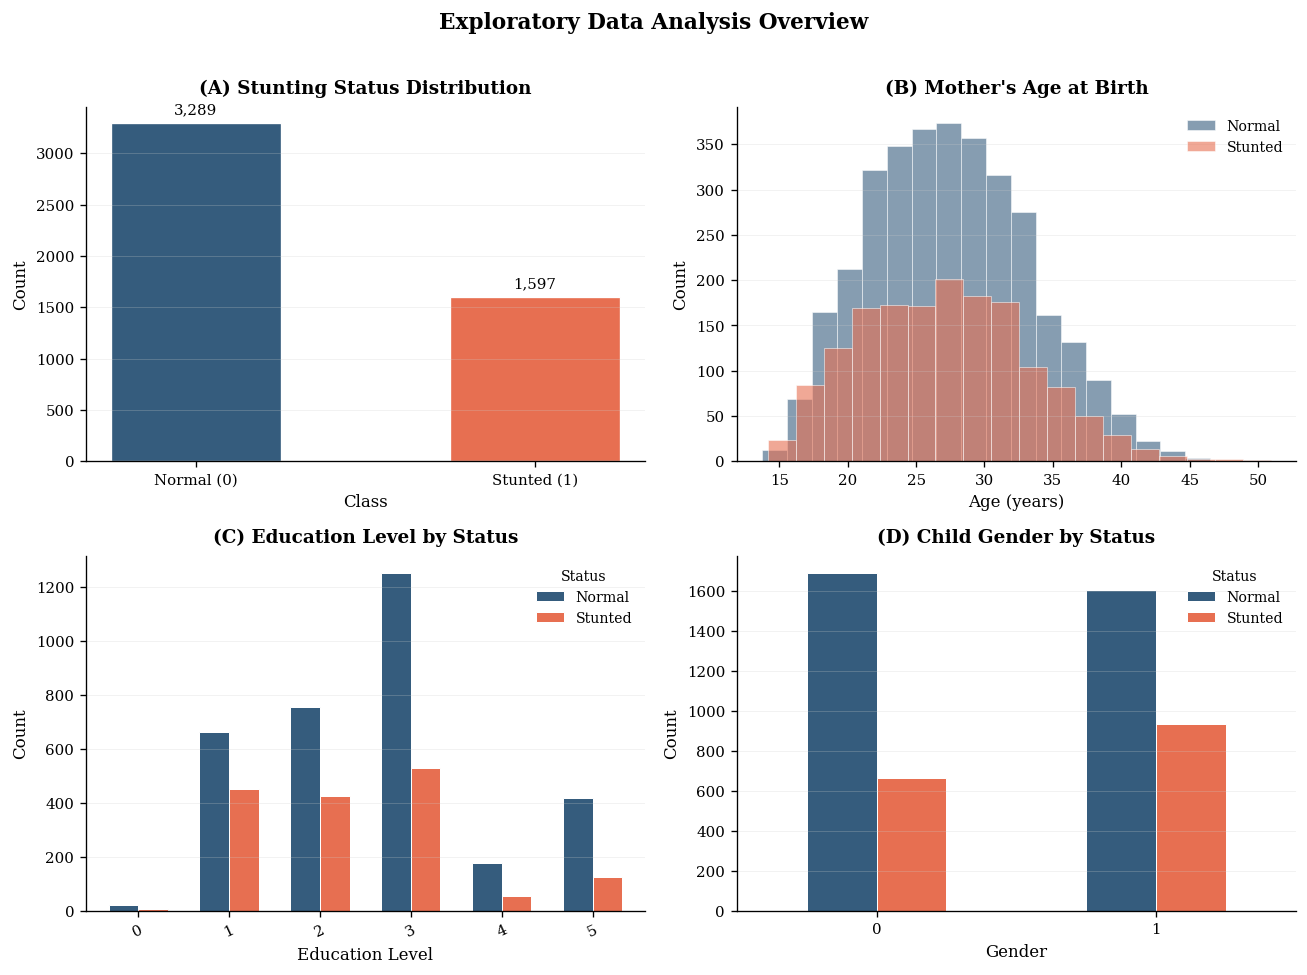

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Exploratory Data Analysis Overview",
             fontsize=13, fontweight="bold", y=1.01)

hue_palette = {"0": PALETTE["primary"], "1": PALETTE["red"],
               0: PALETTE["primary"], 1: PALETTE["red"]}

# ── (A) Target distribution ──────────────────────────────────────
ax = axes[0, 0]
counts = df["is_stunted"].value_counts().sort_index()
bars = ax.bar(["Normal (0)", "Stunted (1)"], counts.values,
              color=[PALETTE["primary"], PALETTE["red"]],
              edgecolor="white", linewidth=0.8, width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.02,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
style_ax(ax, title="(A) Stunting Status Distribution",
         xlabel="Class", ylabel="Count", grid_axis="y")

# ── (B) Mother age by class ───────────────────────────────────────
ax = axes[0, 1]
for val, color, label in [
    (0, PALETTE["primary"], "Normal"),
    (1, PALETTE["red"], "Stunted")
]:
    subset = df.loc[df["is_stunted"] == val, "mother_age_at_birth"]
    ax.hist(subset, bins=18, color=color, alpha=0.60,
            label=label, edgecolor="white", linewidth=0.5)
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax, title="(B) Mother's Age at Birth",
         xlabel="Age (years)", ylabel="Count", grid_axis="y")

# ── (C) Education level by class ─────────────────────────────────
ax = axes[1, 0]
edu_counts = (df.groupby(["mother_education_level", "is_stunted"])
                .size().unstack(fill_value=0))
edu_counts.plot(kind="bar", ax=ax,
                color=[PALETTE["primary"], PALETTE["red"]],
                edgecolor="white", linewidth=0.6, width=0.65)
ax.legend(["Normal", "Stunted"], frameon=False, fontsize=8.5,
          title="Status", title_fontsize=8.5)
style_ax(ax, title="(C) Education Level by Status",
         xlabel="Education Level", ylabel="Count", grid_axis="y")
ax.tick_params(axis="x", rotation=25)

# ── (D) Gender by class ───────────────────────────────────────────
ax = axes[1, 1]
gender_counts = (df.groupby(["child_gender", "is_stunted"])
                   .size().unstack(fill_value=0))
gender_counts.plot(kind="bar", ax=ax,
                   color=[PALETTE["primary"], PALETTE["red"]],
                   edgecolor="white", linewidth=0.6, width=0.5)
ax.legend(["Normal", "Stunted"], frameon=False, fontsize=8.5,
          title="Status", title_fontsize=8.5)
style_ax(ax, title="(D) Child Gender by Status",
         xlabel="Gender", ylabel="Count", grid_axis="y")
ax.tick_params(axis="x", rotation=0)

save_figure(fig, "eda_overview.png")
plt.show()


## 7. Feature Correlation Analysis


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/correlation_matrix.png


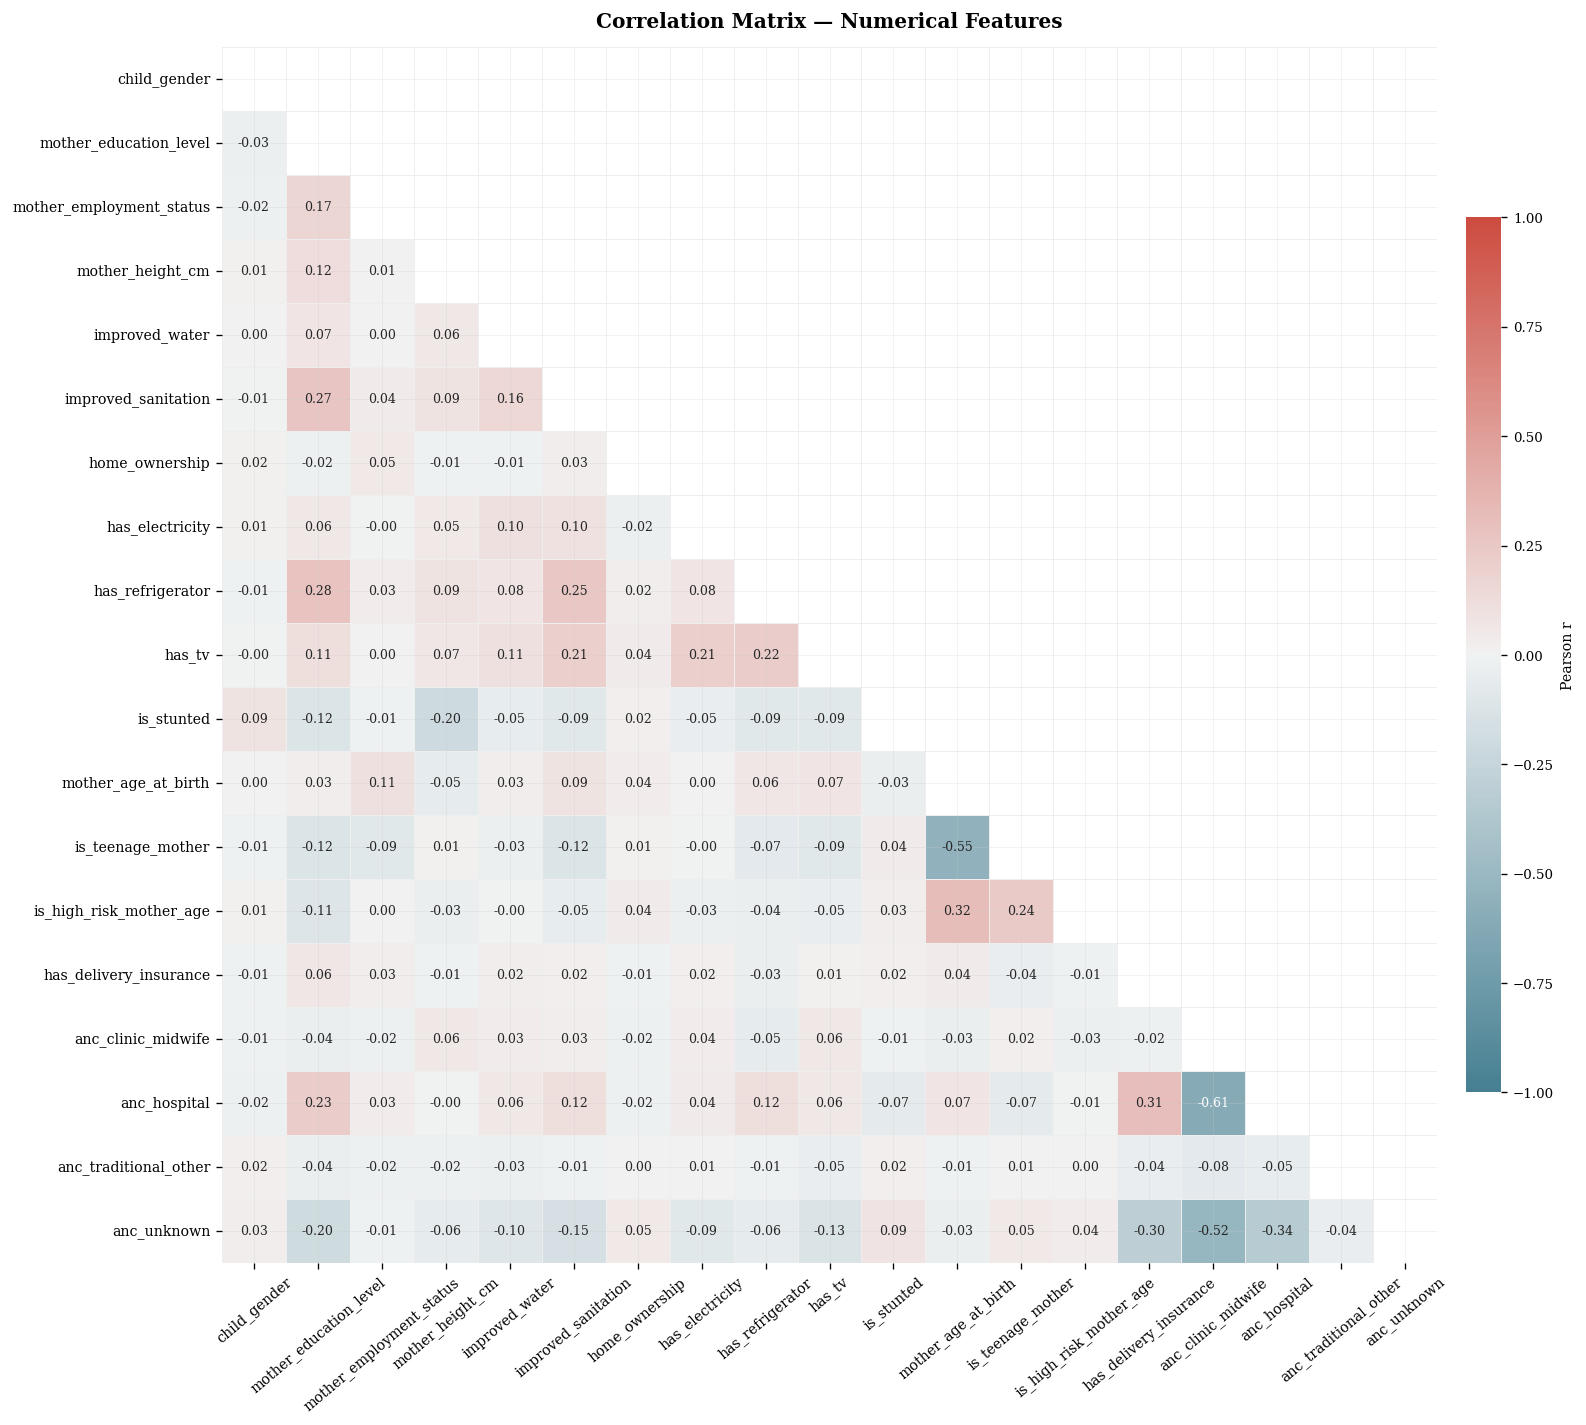

In [6]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

n_feat = corr.shape[0]
fig_size = max(8, n_feat * 0.75)

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

cmap = sns.diverging_palette(220, 15, s=70, l=50, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.4,
    linecolor="#EEEEEE",
    annot_kws={"size": 7.5},
    cbar_kws={"shrink": 0.7, "aspect": 25, "pad": 0.02},
    ax=ax
)

ax.set_title("Correlation Matrix — Numerical Features",
             fontsize=12, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=40, labelsize=8.5)
ax.tick_params(axis="y", rotation=0, labelsize=8.5)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Pearson r", fontsize=8.5)

save_figure(fig, "correlation_matrix.png")
plt.show()


## 8. Train-Test Split

The dataset is split using an 80:20 stratified split to preserve the target class distribution.


In [7]:
X = df.drop(columns=["is_stunted"])
y = df["is_stunted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

print("\nTraining target distribution:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
display((y_test.value_counts(normalize=True) * 100).round(2))


Training set: 3908 samples
Testing set: 978 samples

Training target distribution:


is_stunted
0    67.32
1    32.68
Name: proportion, dtype: float64


Testing target distribution:


is_stunted
0    67.28
1    32.72
Name: proportion, dtype: float64

## 9. Cross-Validation

Five-fold stratified cross-validation is used to estimate model generalization.


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=200, random_state=RANDOM_STATE
    )
}

if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=RANDOM_STATE
    )

scoring = {
    "accuracy": "accuracy",
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv,
                         scoring=scoring, n_jobs=1)
    cv_rows.append({
        "Model": name,
        "Accuracy": f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
        "Recall":   f"{res['test_recall'].mean():.3f} ± {res['test_recall'].std():.3f}",
        "F1":       f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
        "ROC-AUC":  f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df)


,Model,Accuracy,Recall,F1,ROC-AUC
0,Logistic Regression,0.613 ± 0.015,0.599 ± 0.025,0.503 ± 0.015,0.659 ± 0.015
1,Random Forest,0.660 ± 0.007,0.248 ± 0.021,0.323 ± 0.021,0.616 ± 0.013
2,XGBoost,0.617 ± 0.011,0.418 ± 0.014,0.416 ± 0.011,nan ± nan


## 10. Model Training and Evaluation


In [9]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "auc":       roc_auc_score(y_test, y_prob)
    }

metrics_df = pd.DataFrame({
    name: [r["accuracy"], r["precision"], r["recall"], r["f1"], r["auc"]]
    for name, r in results.items()
}, index=["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]).T

display(metrics_df.round(4))

for name, r in results.items():
    print(f"\nClassification Report — {name}")
    print(classification_report(y_test, r["y_pred"]))


Training Logistic Regression...
Training Random Forest...
Training XGBoost...


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.6104,0.4350,0.6375,0.5171,0.6561
Random Forest,0.6575,0.4571,0.2500,0.3232,0.6178
XGBoost,0.6196,0.4207,0.4312,0.4259,0.6067



Classification Report — Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.60      0.67       658
           1       0.43      0.64      0.52       320

    accuracy                           0.61       978
   macro avg       0.60      0.62      0.60       978
weighted avg       0.66      0.61      0.62       978


Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       658
           1       0.46      0.25      0.32       320

    accuracy                           0.66       978
   macro avg       0.58      0.55      0.55       978
weighted avg       0.62      0.66      0.62       978


Classification Report — XGBoost
              precision    recall  f1-score   support

           0       0.72      0.71      0.72       658
           1       0.42      0.43      0.43       320

    accuracy                           0.62       978
   macro av

## 11. ROC Curve Comparison


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/roc_curves.png


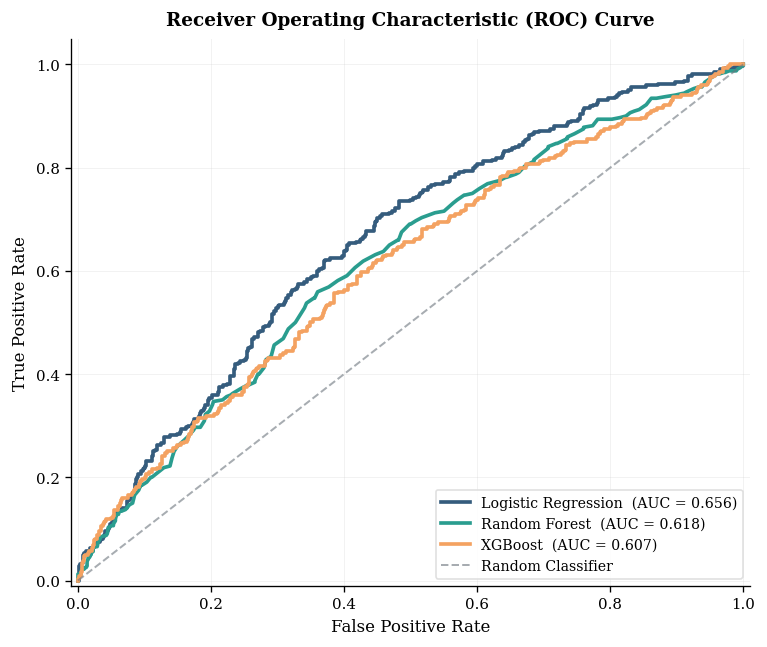

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for idx, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr,
            color=get_model_color(idx),
            linewidth=2.2,
            label=f"{name}  (AUC = {r['auc']:.3f})")

# Soft diagonal reference
ax.plot([0, 1], [0, 1],
        linestyle="--", linewidth=1.2,
        color=PALETTE["gray"], alpha=0.6, label="Random Classifier")

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.05)
style_ax(ax,
         title="Receiver Operating Characteristic (ROC) Curve",
         xlabel="False Positive Rate",
         ylabel="True Positive Rate",
         grid_axis="both")

ax.legend(loc="lower right", frameon=True,
          framealpha=0.9, edgecolor="#DDDDDD",
          fontsize=8.5)

save_figure(fig, "roc_curves.png")
plt.show()


## 12. Metric Comparison


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/metric_comparison.png


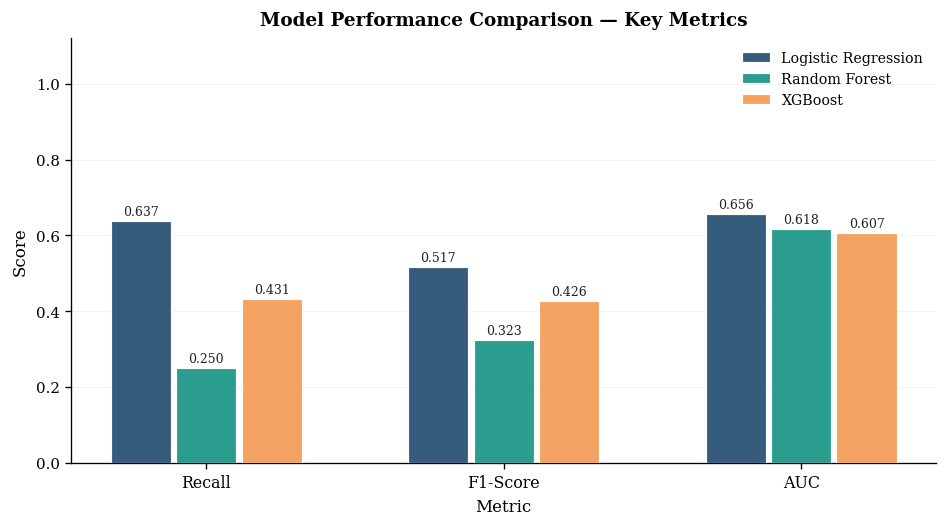

In [11]:
metric_cols = ["Recall", "F1-Score", "AUC"]
plot_data = metrics_df[metric_cols].copy()

fig, ax = plt.subplots(figsize=(8, 4.5))

n_models  = len(plot_data)
n_metrics = len(metric_cols)
x         = np.arange(n_metrics)
width     = 0.22
offsets   = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for i, (model_name, row) in enumerate(plot_data.iterrows()):
    bars = ax.bar(x + offsets[i], row.values,
                  width=width * 0.92,
                  color=get_model_color(i),
                  edgecolor="white", linewidth=0.7,
                  label=model_name, zorder=3)
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{val:.3f}",
                ha="center", va="bottom",
                fontsize=7.5, color="#222222")

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=9.5)
ax.set_ylim(0, 1.12)
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax,
         title="Model Performance Comparison — Key Metrics",
         xlabel="Metric", ylabel="Score",
         grid_axis="y")

save_figure(fig, "metric_comparison.png")
plt.show()


## 13. Confusion Matrices


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/confusion_matrices.png


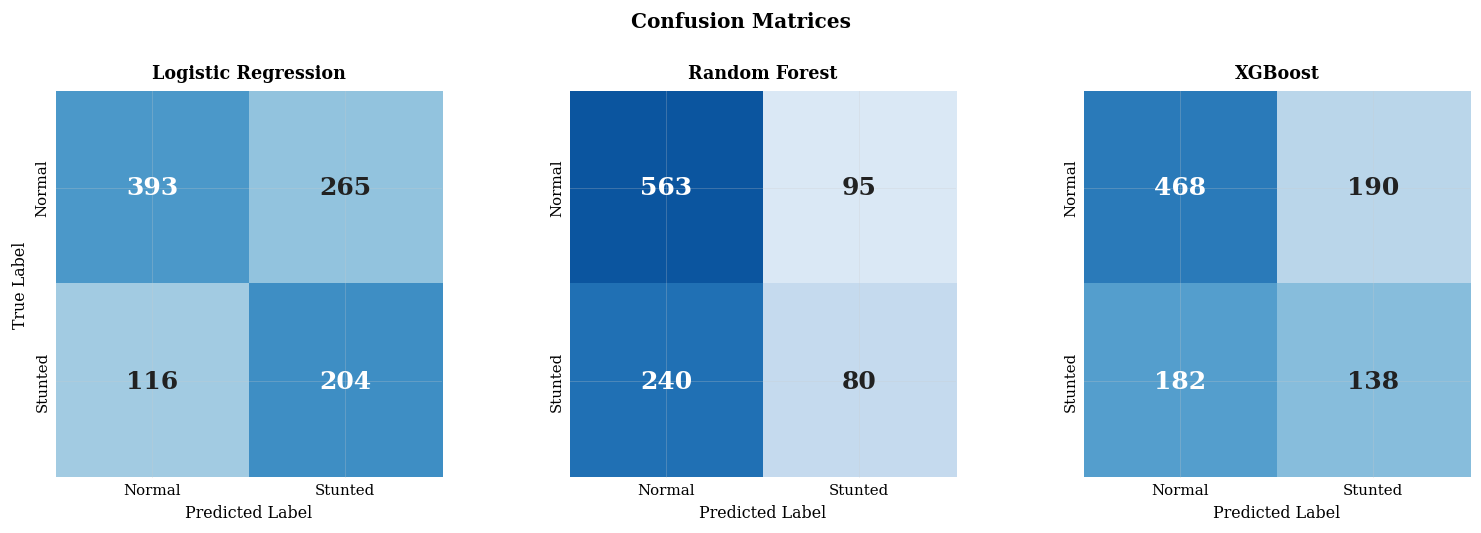

In [12]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models,
                          figsize=(4.4 * n_models, 4.2),
                          squeeze=False)

for col, (name, r) in enumerate(results.items()):
    ax = axes[0, col]
    cm = confusion_matrix(y_test, r["y_pred"])

    # Normalize for coloring while showing raw counts
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="equal")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = "white" if cm_norm[i, j] > 0.55 else "#222222"
            ax.text(j, i, f"{cm[i, j]:,}",
                    ha="center", va="center",
                    fontsize=15, fontweight="bold",
                    color=text_color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Stunted"], fontsize=9)
    ax.set_yticklabels(["Normal", "Stunted"], fontsize=9, rotation=90,
                       va="center")
    ax.set_xlabel("Predicted Label", fontsize=9.5)
    if col == 0:
        ax.set_ylabel("True Label", fontsize=9.5)
    ax.set_title(name, fontsize=10.5, fontweight="bold", pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(length=0)

fig.suptitle("Confusion Matrices", fontsize=12, fontweight="bold", y=1.02)
save_figure(fig, "confusion_matrices.png")
plt.show()


## 14. Best Model Selection


In [13]:
best_name = max(
    results,
    key=lambda x: (results[x]["f1"], results[x]["recall"], results[x]["auc"])
)
best_model = results[best_name]["model"]

print(f"Best model : {best_name}")
print(f"F1-Score   : {results[best_name]['f1']:.4f}")
print(f"Recall     : {results[best_name]['recall']:.4f}")
print(f"AUC        : {results[best_name]['auc']:.4f}")


Best model : Logistic Regression
F1-Score   : 0.5171
Recall     : 0.6375
AUC        : 0.6561


## 15. Threshold Tuning


In [14]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
tuning_rows = []
y_best_prob = results[best_name]["y_prob"]

for threshold in thresholds:
    pred_t = (y_best_prob >= threshold).astype(int)
    tuning_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred_t),
        "Recall":    recall_score(y_test, pred_t),
        "F1-Score":  f1_score(y_test, pred_t)
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df.round(4))

best_tune        = tuning_df.loc[tuning_df["F1-Score"].idxmax()]
optimal_threshold = float(best_tune["Threshold"])

print(f"\nOptimal threshold : {optimal_threshold}")
print(f"Precision         : {best_tune['Precision']:.4f}")
print(f"Recall            : {best_tune['Recall']:.4f}")
print(f"F1-Score          : {best_tune['F1-Score']:.4f}")


,Threshold,Precision,Recall,F1-Score
0,0.30,0.3472,0.9625,0.5104
1,0.35,0.3651,0.9219,0.5230
2,0.40,0.3837,0.8406,0.5269
3,0.45,0.4126,0.7594,0.5347
4,0.50,0.4350,0.6375,0.5171



Optimal threshold : 0.45
Precision         : 0.4126
Recall            : 0.7594
F1-Score          : 0.5347


### Threshold Tuning Visualization


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/threshold_tuning.png


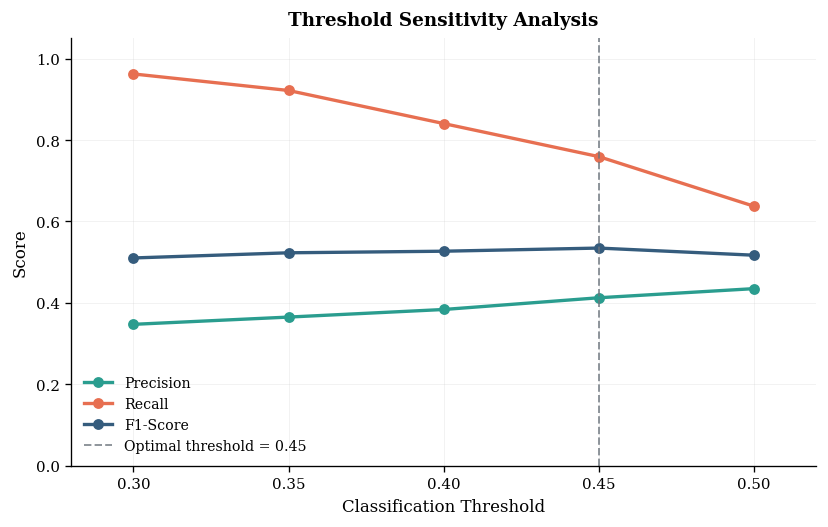

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for metric, color in [
    ("Precision", PALETTE["teal"]),
    ("Recall",    PALETTE["red"]),
    ("F1-Score",  PALETTE["primary"]),
]:
    ax.plot(tuning_df["Threshold"], tuning_df[metric],
            marker="o", markersize=5.5, linewidth=2.0,
            color=color, label=metric)

ax.axvline(optimal_threshold, linestyle="--",
           color=PALETTE["gray"], linewidth=1.2, alpha=0.75,
           label=f"Optimal threshold = {optimal_threshold}")

ax.set_xlim(min(thresholds) - 0.02, max(thresholds) + 0.02)
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax,
         title="Threshold Sensitivity Analysis",
         xlabel="Classification Threshold",
         ylabel="Score",
         grid_axis="both")

save_figure(fig, "threshold_tuning.png")
plt.show()


## 16. Save Model Artifacts


In [16]:
comparison = pd.DataFrame([
    {
        "Model": name,
        "Accuracy":  r["accuracy"],
        "Precision": r["precision"],
        "Recall":    r["recall"],
        "F1":        r["f1"],
        "ROC-AUC":   r["auc"]
    }
    for name, r in results.items()
])

joblib.dump(best_model,            MODEL_DIR / "stunting_model.pkl")
joblib.dump(list(X.columns),       MODEL_DIR / "feature_columns.pkl")
joblib.dump(optimal_threshold,     MODEL_DIR / "stunting_threshold.pkl")

comparison.to_csv(PROJECT_ROOT / "Data/processed/07_model_comparison.csv", index=False)
tuning_df.to_csv(PROJECT_ROOT / "Data/processed/07_threshold_tuning.csv", index=False)

print("All Step 7 artifacts saved.")


All Step 7 artifacts saved.


---

# Step 8: Explainable AI

SHAP is used as the primary XAI method because it supports both global and local interpretation. LIME is used as a local comparison method.


## 17. SHAP — Global Interpretability Setup


In [17]:
if not SHAP_AVAILABLE:
    raise ImportError("SHAP is not installed. Run: pip install shap")

if isinstance(best_model, LogisticRegression):
    explainer = shap.LinearExplainer(best_model, X_train)
else:
    explainer = shap.TreeExplainer(best_model)

shap_values_raw = explainer.shap_values(X_test)

if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
else:
    shap_vals = shap_values_raw

print("SHAP values shape:", np.array(shap_vals).shape)


SHAP values shape: (978, 18)


## 18. SHAP Summary Plot


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_summary.png


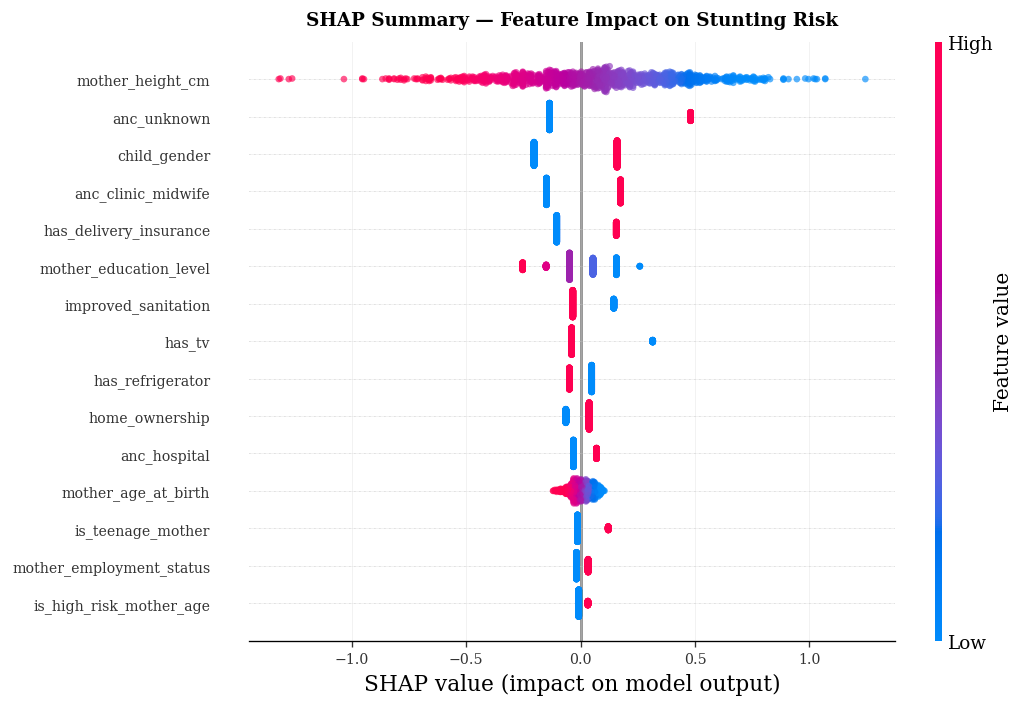

In [18]:
# Override rcParams temporarily for SHAP's internal plotting
shap_plot_rc = {
    "font.family":    "serif",
    "font.serif":     ["DejaVu Serif", "Times New Roman", "serif"],
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}

with plt.rc_context(shap_plot_rc):
    fig_shap, ax_shap = plt.subplots(figsize=(9, 6))

    shap.summary_plot(
        shap_vals, X_test,
        plot_type="dot",
        show=False,
        color_bar=True,
        plot_size=None,
        alpha=0.65,
        max_display=min(15, X_test.shape[1])
    )

    ax_shap = plt.gca()
    ax_shap.set_title("SHAP Summary — Feature Impact on Stunting Risk",
                      fontsize=11, fontweight="bold", pad=10)
    ax_shap.spines["top"].set_visible(False)
    ax_shap.spines["right"].set_visible(False)
    ax_shap.tick_params(labelsize=8.5)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "shap_summary.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  Saved → {FIGURE_DIR / 'shap_summary.png'}")
    plt.show()


## 19. SHAP Feature Importance (Bar Chart)


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_feature_importance.png


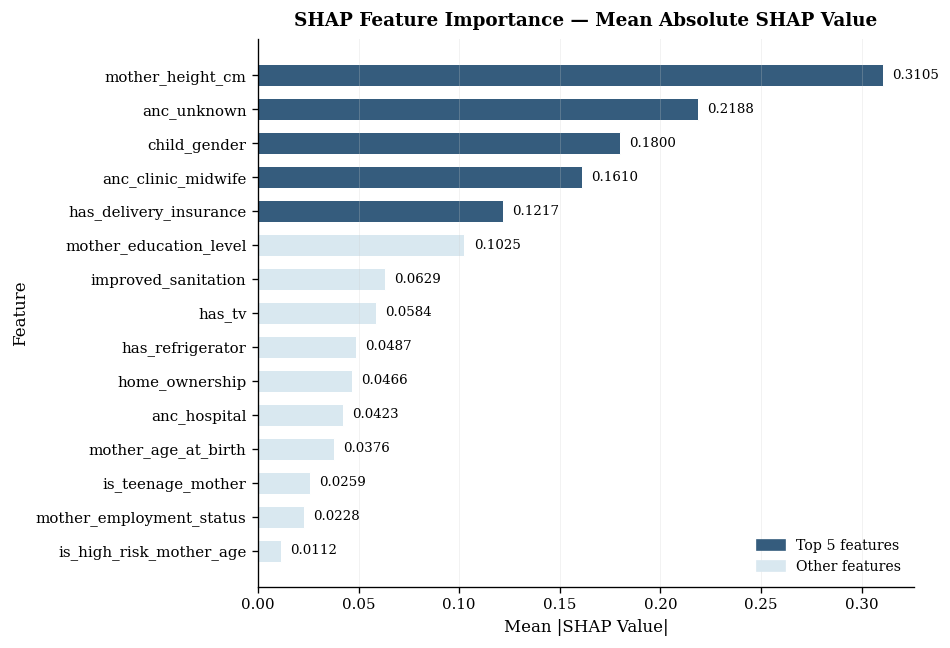

,Feature,Mean |SHAP|
0,mother_height_cm,0.310520
1,anc_unknown,0.218791
2,child_gender,0.180022
3,anc_clinic_midwife,0.160970
4,has_delivery_insurance,0.121674
5,mother_education_level,0.102512
6,improved_sanitation,0.062882
7,has_tv,0.058442
8,has_refrigerator,0.048693
9,home_ownership,0.046633


In [19]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature":    list(X.columns),
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

top_n   = min(15, len(shap_importance))
plot_df = shap_importance.head(top_n).iloc[::-1]  # ascending for barh

# Color-grade: top features highlighted
bar_colors = [
    PALETTE["primary"] if i >= top_n - 5 else PALETTE["light"]
    for i in range(top_n)
]

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.barh(plot_df["Feature"], plot_df["Mean |SHAP|"],
               color=bar_colors, edgecolor="white", linewidth=0.6,
               height=0.65)

for bar, val in zip(bars, plot_df["Mean |SHAP|"]):
    ax.text(bar.get_width() + plot_df["Mean |SHAP|"].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left", fontsize=8)

style_ax(ax,
         title="SHAP Feature Importance — Mean Absolute SHAP Value",
         xlabel="Mean |SHAP Value|",
         ylabel="Feature",
         grid_axis="x")

# Legend for highlight
legend_patches = [
    mpatches.Patch(color=PALETTE["primary"], label="Top 5 features"),
    mpatches.Patch(color=PALETTE["light"],   label="Other features"),
]
ax.legend(handles=legend_patches, frameon=False, fontsize=8.5,
          loc="lower right")

save_figure(fig, "shap_feature_importance.png")
plt.show()

shap_importance_sorted = shap_importance.sort_values("Mean |SHAP|", ascending=False)
display(shap_importance_sorted)
shap_importance_sorted.to_csv(
    PROJECT_ROOT / "Data/processed/08_shap_feature_importance.csv", index=False
)


## 20. SHAP Waterfall Plot

This plot explains one stunted sample, showing how each feature drives the prediction above or below the baseline.


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/shap_waterfall_sample.png


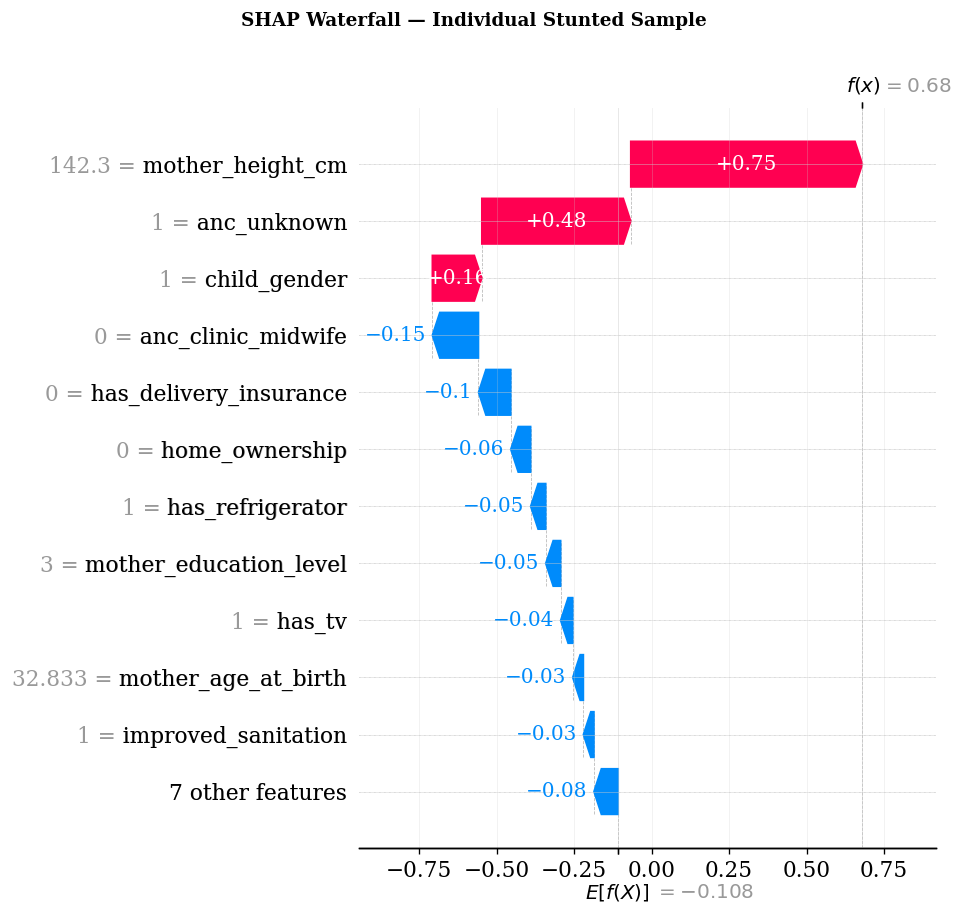

In [20]:
stunted_indices = np.where(y_test.values == 1)[0]
sample_idx = stunted_indices[0] if len(stunted_indices) > 0 else 0
sample_x   = X_test.iloc[sample_idx]

if isinstance(best_model, LogisticRegression):
    base_value = explainer.expected_value
else:
    expected_value = explainer.expected_value
    base_value = (expected_value[1]
                  if isinstance(expected_value, (list, np.ndarray))
                  else expected_value)

explanation = shap.Explanation(
    values=shap_vals[sample_idx],
    base_values=base_value,
    data=sample_x.values,
    feature_names=list(X.columns)
)

with plt.rc_context({
    "font.family":    "serif",
    "font.serif":     ["DejaVu Serif", "Times New Roman", "serif"],
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
}):
    fig_wf = plt.figure(figsize=(9, 5.5))
    shap.waterfall_plot(explanation, show=False, max_display=12)
    plt.gcf().suptitle("SHAP Waterfall — Individual Stunted Sample",
                        fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "shap_waterfall_sample.png",
                dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  Saved → {FIGURE_DIR / 'shap_waterfall_sample.png'}")
    plt.show()


## 21. LIME Local Explanation


In [21]:
if not LIME_AVAILABLE:
    raise ImportError("LIME is not installed. Run: pip install lime")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Normal", "Stunted"],
    mode="classification",
    random_state=RANDOM_STATE
)

exp = lime_explainer.explain_instance(
    data_row=sample_x.values,
    predict_fn=best_model.predict_proba,
    num_features=len(X.columns)
)

lime_df = pd.DataFrame(exp.as_list(), columns=["Feature Rule", "Weight"])
lime_df["Direction"] = np.where(
    lime_df["Weight"] > 0,
    "Increases stunting risk",
    "Decreases stunting risk"
)
lime_df["Abs Weight"] = lime_df["Weight"].abs()
lime_df = lime_df.sort_values("Abs Weight", ascending=True).reset_index(drop=True)

display(lime_df.sort_values("Abs Weight", ascending=False).head(10))


,Feature Rule,Weight,Direction,Abs Weight
17,mother_height_cm <= 148.00,0.170904,Increases stunting risk,0.170904
16,anc_unknown > 0.00,0.142068,Increases stunting risk,0.142068
15,anc_traditional_other <= 0.00,-0.103594,Decreases stunting risk,0.103594
14,0.00 < child_gender <= 1.00,0.085520,Increases stunting risk,0.085520
13,anc_clinic_midwife <= 0.00,-0.077816,Decreases stunting risk,0.077816
12,has_delivery_insurance <= 0.00,-0.060221,Decreases stunting risk,0.060221
11,anc_hospital <= 0.00,-0.026044,Decreases stunting risk,0.026044
10,home_ownership <= 0.00,-0.025213,Decreases stunting risk,0.025213
9,is_teenage_mother <= 0.00,-0.024057,Decreases stunting risk,0.024057
8,0.00 < has_refrigerator <= 1.00,-0.023321,Decreases stunting risk,0.023321


## 22. LIME Visualization


  Saved → /Users/arya/Documents/Tugas Akhir/stunting ml/models/figures/lime_explanation_sample.png


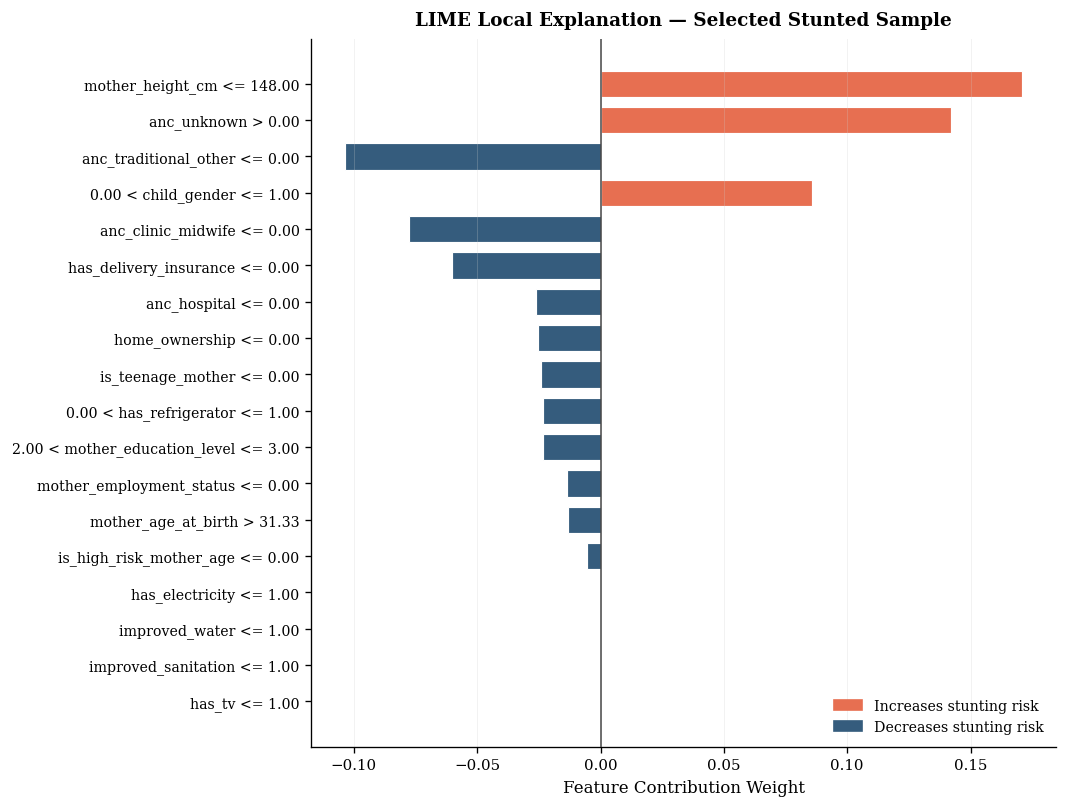

In [22]:
bar_colors = lime_df["Weight"].apply(
    lambda w: PALETTE["red"] if w > 0 else PALETTE["primary"]
)

fig, ax = plt.subplots(figsize=(9, max(5, len(lime_df) * 0.38)))

ax.barh(lime_df["Feature Rule"], lime_df["Weight"],
        color=bar_colors,
        edgecolor="white", linewidth=0.7,
        height=0.72)

ax.axvline(0, color="#444444", linewidth=0.9, zorder=5)

style_ax(ax,
         title="LIME Local Explanation — Selected Stunted Sample",
         xlabel="Feature Contribution Weight",
         ylabel=None,
         grid_axis="x")

ax.tick_params(axis="y", labelsize=8.5)

legend_patches = [
    mpatches.Patch(color=PALETTE["red"],     label="Increases stunting risk"),
    mpatches.Patch(color=PALETTE["primary"], label="Decreases stunting risk"),
]
ax.legend(handles=legend_patches, frameon=False, fontsize=8.5,
          loc="lower right")

save_figure(fig, "lime_explanation_sample.png")
plt.show()


## 23. SHAP vs. LIME Comparison

| Method | Scope | Strengths | Limitations | Role in Study |
|---|---|---|---|---|
| **SHAP** | Global + Local | Mathematically consistent (Shapley values); stable across runs | Higher computational cost for large datasets | **Primary XAI method** |
| **LIME** | Local only | Intuitive; approximates local decision boundary | Less stable due to local random sampling | Local comparison baseline |


## 24. XAI Validation Summary


In [23]:
print(f"Best model       : {best_name}")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Feature count    : {X_train.shape[1]}")
print(f"SHAP available   : {SHAP_AVAILABLE}")
print(f"LIME available   : {LIME_AVAILABLE}")

print("\nSaved figures:")
for fig_path in sorted(FIGURE_DIR.glob("*.png")):
    print(f"  {fig_path.name}")

print("\nSaved model artifacts:")
for artifact_path in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"  {artifact_path.name}")


Best model       : Logistic Regression
Training samples : 3908
Testing samples  : 978
Feature count    : 18
SHAP available   : True
LIME available   : True

Saved figures:
  confusion_matrices.png
  correlation_matrix.png
  eda_overview.png
  lime_explanation_sample.png
  metric_comparison.png
  model_comparison.png
  roc_and_importance.png
  roc_curves.png
  shap_bar.png
  shap_feature_importance.png
  shap_summary.png
  shap_waterfall_sample.png
  threshold_tuning.png

Saved model artifacts:
  feature_columns.pkl
  stunting_model.pkl
  stunting_threshold.pkl


## 25. Interpretation

SHAP is used as the main Explainable AI method because it provides both global and local feature attribution with mathematical consistency (grounded in Shapley values from cooperative game theory), while LIME serves as a local comparison method. The moderate model performance reflects the multifactorial nature of stunting, where maternal and socioeconomic variables explain only part of the risk. Therefore, the model is positioned as an **early warning system** for Prenava, not as a definitive diagnostic tool.
